<a href="https://colab.research.google.com/github/Maurofome/Lab01_EDA_Aliaga_Mauricio/blob/main/EvU1_Satisfaccion_Aerolinea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Parte A — El problema**

Fase CRISP-DM: Bussines Understanding

• Contexto: El dataset reune una gran cantidad de encuestas que se realizaron al final de vuelo de pasajeros, en donde la encuesta se evaluan varios aspectos de la experiencia de vuelo. Estos pueden ser utilizados por la aerolinea o el area de servicio al cliente.

• Objetivo: Decidir que aspectos del vuelo se pueden mejorar para la experiencia de vuelo.

• Un promedio solo me dice cuántos pasajeros quedaron satisfechos, pero no por qué. Este dataset tiene más de 129.000 encuestas y muchas variables , así que es imposible ver a simple vista qué factores influyen. La minería de datos permite descubrir esos patrones automáticamente y usarlos para decidir qué mejorar.


**Parte B — Los datos **
Fase CRISP-DM: Data understanding.

• Fuente:
Nombre: Airline Satisfaction Data ✈️
Autor u organización: Arseniy Shutko
Enlace: https://www.kaggle.com/datasets/arseniyshutko/binary-aviation-satisfaction-129k/data
Licencia: This dataset is released under CC0 (Dominio Publico).
• Diccionario de al menos 10 atributos:

- "Class" es de tipo categórico y	permite ver si la satisfacción cambia según el nivel de servicio contratado.
- "Type of Travel" de tipo categórico	muestra si los pasajeros que viajan por trabajo y los que viajan por placer valoran distinto el servicio.
- "Customer Type"	tipo categórico y permite saber si los clientes frecuentes están más o menos satisfechos que los ocasionales.
- "Age"	de tipo numérico y permite detectar si la satisfacción varía según la edad del pasajero.
- "Flight Distance"	de tipo numérico y permite ver si el largo del vuelo influye en la satisfacción, por ejemplo si en vuelos largos importa más la comodidad.
- "Seat comfort" tipo	ordinal e	indica si la comodidad del asiento pesa en la satisfacción, y es un aspecto que la aerolínea puede mejorar.
- "Inflight wifi service"	tipo ordinal y permite saber si el wifi es un factor relevante, y es una inversión concreta que la aerolínea puede decidir.
- "Food and drink"	tipo ordinal y	muestra cuánto influye la comida y bebida en la experiencia de vuelo.
- "Cleanliness"	tipo ordinal y	permite ver si la limpieza se asocia con la satisfacción.
- "Departure Delay in Minutes"	tipo numérico	y permite ver si los retrasos afectan la satisfacción, una decisión operativa importante.


In [30]:
#Carga de Dataset
import pandas as pd
from google.colab import files

subido = files.upload()  # elige airline_satisfaction_data.csv
df = pd.read_csv("airline_satisfaction_data.csv")

Saving airline_satisfaction_data.csv to airline_satisfaction_data (1).csv


Se selecciona el dataset y se súbe

In [31]:
#Dimensiones
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 129880
Columnas: 22


El número de filas y columnas, se supera el requirimento de 50000 filas pero se consulto al profesor.

In [32]:
#Primeras Filas
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True


Qué tipo de información trae cada fila y qué grupos de columnas notas.

**Parte C — Exploración y preparación (EDA)**
Fase(s) CRISP-DM: identifícalas tú.


In [33]:
#Estructura y tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    1298

Existen 17 columnas numericas (16 int64 y 1 float64), 1 de tipo bool (Siendo esta "satisfaction" y 4 de texto (object).

In [34]:
#Nulos y duplicados
print(df.isnull().sum())
print("Duplicados:", df.duplicated().sum())

# ¿Qué retraso de salida tienen los pasajeros con nulo en Arrival Delay?
nulos = df[df["Arrival Delay in Minutes"].isnull()]
nulos["Departure Delay in Minutes"].describe()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64
Duplicados: 0


,Departure Delay in Minutes
count,393.000000
mean,37.885496
std,66.213936
min,0.000000
25%,0.000000
50%,8.000000
75%,48.000000
max,530.000000


Existen 393 nulos en "Arrival Delay in Minutes" y ningun duplicado. Se dio la hipotesis de que estos nulos podrian ser vuelos sin retraso alguno pero esto fue descartado porque varios de esos pasajeros tuvieron salidas retrasadas.

La mitad de estos pasajeros salió con 8 minutos de retraso o menos, pero hubo casos de hasta 530 minutos. Esa variedad muestra que sí hay información de retraso en este grupo, así que los nulos son datos faltantes y son datos que no se registraron.

**Decision**
Eliminar las filas ya que son el 0,3 % del total, así que se pierde muy poco y no distorsiona el análisis.

In [35]:
filas_antes = df.shape[0]
df = df.dropna(subset=["Arrival Delay in Minutes"])
print("Filas antes:", filas_antes)
print("Filas después:", df.shape[0])
print("Nulos restantes:", df.isnull().sum().sum())

Filas antes: 129880
Filas después: 129487
Nulos restantes: 0


Se aplica codigo para eliminar las filas nulas

In [36]:
df[["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]].describe()

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,129487.000000,129487.000000,129487.000000,129487.000000
mean,39.428761,1190.210662,14.643385,15.091129
std,15.117597,997.560954,37.932867,38.465650
min,7.000000,31.000000,0.000000,0.000000
25%,27.000000,414.000000,0.000000,0.000000
50%,40.000000,844.000000,0.000000,0.000000
75%,51.000000,1744.000000,12.000000,13.000000
max,85.000000,4983.000000,1592.000000,1584.000000


Se decide que los valores extremos de retraso (más de 1.500 minutos) es dejarlos, porque son datos reales de retrasos largos y no errores evidentes. Estos pueden afectar el promedio o puede hasta ser un dato dudoso.

In [37]:
filas_antes = df.shape[0]
df = df[(df["Departure Delay in Minutes"] < 1500) & (df["Arrival Delay in Minutes"] < 1500)]
print("Filas antes:", filas_antes)
print("Filas después:", df.shape[0])

Filas antes: 129487
Filas después: 129486


Se elimina la fila

In [38]:
#Variable objetivo
print(df["satisfaction"].value_counts())
print(df["satisfaction"].value_counts(normalize=True))

satisfaction
False    73224
True     56262
Name: count, dtype: int64
satisfaction
False    0.565497
True     0.434503
Name: proportion, dtype: float64


Hay más pasajeros no satisfechos que satisfechos, pero la diferencia es de unos 13 puntos( False: 0.565497 True: 0.434503), así que las clases están razonablemente equilibradas. Esto evita que el árbol y las reglas se inclinen hacia una sola clase.

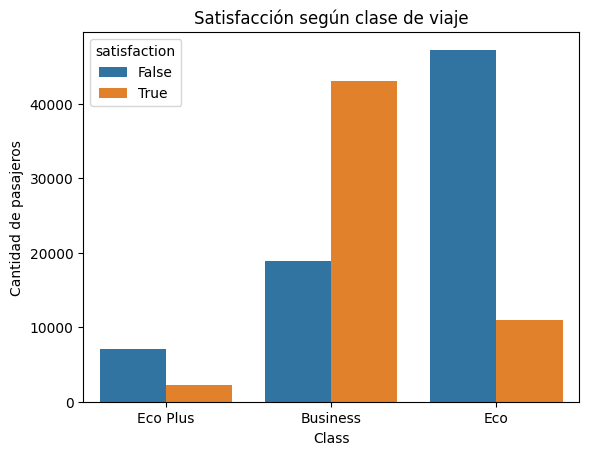

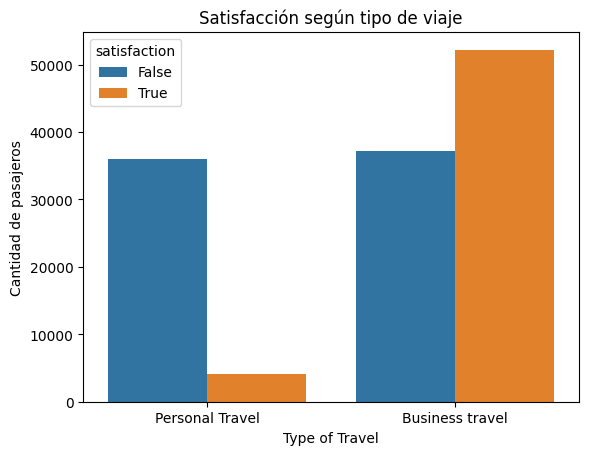

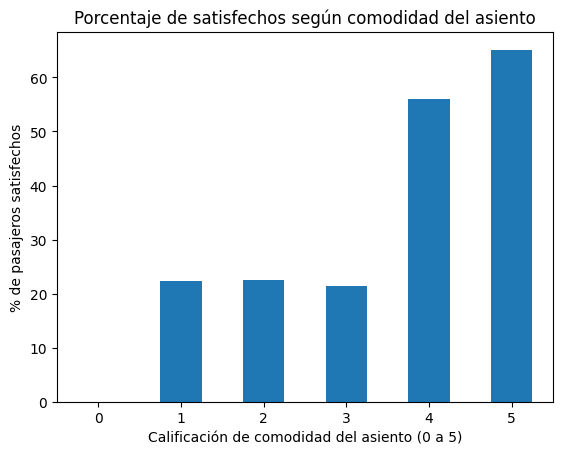

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización 1: satisfacción según clase
sns.countplot(data=df, x="Class", hue="satisfaction")
plt.title("Satisfacción según clase de viaje")
plt.ylabel("Cantidad de pasajeros")
plt.show()

# Visualización 2: satisfacción según tipo de viaje
sns.countplot(data=df, x="Type of Travel", hue="satisfaction")
plt.title("Satisfacción según tipo de viaje")
plt.ylabel("Cantidad de pasajeros")
plt.show()

#Visusualizacion 3: Satisfaccion segun comodidad del asiento.
sat_asiento = df.groupby("Seat comfort")["satisfaction"].mean() * 100

sat_asiento.plot(kind="bar")
plt.title("Porcentaje de satisfechos según comodidad del asiento")
plt.xlabel("Calificación de comodidad del asiento (0 a 5)")
plt.ylabel("% de pasajeros satisfechos")
plt.xticks(rotation=0)
plt.show()

En Business la mayoría queda satisfecha, mientras que en Eco y Eco Plus la mayoría no.
En cambio en los viajes de negocios queda satisfecho cerca del 58 %, y en viajes personales solo cerca del 10 %.

Las mejoras del servicio deberían enfocarse primero en los pasajeros de clase Eco y de viajes personales, donde la satisfacción es más baja
Hay un salto fuerte en la comodidad del asiento entre 3 y 4 ya que pasa de cerca del 22 % de satisfechos con nota 3 a cerca del 56 % con nota 4. Parece que una nota de 4 o más en comodidad marca la diferencia.


In [40]:
columnas_servicio = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink",
    "Online boarding", "Seat comfort", "Inflight entertainment",
    "On-board service", "Leg room service", "Baggage handling",
    "Checkin service", "Cleanliness"
]
print((df[columnas_servicio] == 0).sum())

Inflight wifi service                3908
Departure/Arrival time convenient    6664
Ease of Online booking               5666
Gate location                           1
Food and drink                        130
Online boarding                      3071
Seat comfort                            1
Inflight entertainment                 18
On-board service                        5
Leg room service                      596
Baggage handling                        0
Checkin service                         1
Cleanliness                            14
dtype: int64


Según la documentación del dataset, el valor 0 en las calificaciones de servicio significa "no calificado" ("1–5 or 0 (0 = not rated)"). Decidí mantener estas filas porque si se eliminan se perderían miles de registros, y las trataré como una categoría aparte en las reglas de asociación. No eliminé columnas porque el dataset no trae identificadores ni nombres.

**Parte D — Reglas de asociación**
Fase CRISP-DM: identifícala tú.

Elegí 5 columnas: satisfaction, Class, Type of Travel, Customer Type y Seat comfort. Elegí la satisfacción porque es lo que quiero explicar. Elegí las otras porque en el EDA vi que se relacionan con ella, y la comodidad del asiento es algo que la aerolínea puede mejorar.

In [41]:
import pandas as pd

def agrupar(nota):
    if nota == 0:
        return "No calificó"
    elif nota <= 2:
        return "Baja"
    elif nota == 3:
        return "Media"
    else:
        return "Alta"

reglas = pd.DataFrame()
reglas["Satisfacción"] = df["satisfaction"].map({True: "Satisfecho", False: "No satisfecho"})
reglas["Clase"] = df["Class"]
reglas["Tipo viaje"] = df["Type of Travel"]
reglas["Tipo cliente"] = df["Customer Type"]
reglas["Comodidad asiento"] = df["Seat comfort"].apply(agrupar)

reglas_bin = pd.get_dummies(reglas).astype(bool)
print(reglas_bin.shape)
reglas_bin.head()

(129486, 13)


,Satisfacción_No satisfecho,Satisfacción_Satisfecho,Clase_Business,Clase_Eco,Clase_Eco Plus,Tipo viaje_Business travel,Tipo viaje_Personal Travel,Tipo cliente_Loyal Customer,Tipo cliente_disloyal Customer,Comodidad asiento_Alta,Comodidad asiento_Baja,Comodidad asiento_Media,Comodidad asiento_No calificó
0,True,False,False,False,True,False,True,True,False,True,False,False,False
1,True,False,True,False,False,True,False,False,True,False,True,False,False
2,False,True,True,False,False,True,False,True,False,True,False,False,False
3,True,False,True,False,False,True,False,True,False,False,True,False,False
4,False,True,True,False,False,True,False,True,False,True,False,False,False


El algoritmo solo entiende si algo está presente o ausente, así que agrupé la comodidad del asiento en 4 categorías: "No calificó" (0), "Baja" (1 y 2), "Media" (3) y "Alta" (4 y 5). Usé ese corte por el salto que vi en el gráfico entre las notas 3 y 4. Después convertí cada categoría en una columna de verdadero o falso. Quedaron 129.486 filas y 13 columnas.

In [42]:
from mlxtend.frequent_patterns import apriori

frecuentes = apriori(reglas_bin, min_support=0.05, use_colnames=True)
print("Conjuntos frecuentes:", len(frecuentes))
frecuentes.sort_values("support", ascending=False).head(10)

Conjuntos frecuentes: 142


,support,itemsets
7,0.816861,(Tipo cliente_Loyal Customer)
5,0.690770,(Tipo viaje_Business travel)
0,0.565497,(Satisfacción_No satisfecho)
9,0.561505,(Comodidad asiento_Alta)
42,0.509167,"(Tipo viaje_Business travel, Tipo cliente_Loyal Customer)"
51,0.487875,"(Comodidad asiento_Alta, Tipo cliente_Loyal Customer)"
2,0.478739,(Clase_Business)
28,0.458158,"(Tipo viaje_Business travel, Clase_Business)"
3,0.448821,(Clase_Eco)
1,0.434503,(Satisfacción_Satisfecho)


Usé Apriori con un support mínimo de 0,05, es decir, solo guarda combinaciones que aparecen en al menos el 5 % de los pasajeros. Resultaron 142 conjuntos. Por ejemplo, el 82 % de los pasajeros es cliente leal y el 69 % viaja por negocios. Hasta aquí el algoritmo solo cuenta qué aparece junto, todavía no hay reglas.

In [43]:
from mlxtend.frequent_patterns import association_rules

reglas_asoc = association_rules(frecuentes, metric="confidence", min_threshold=0.6)
print("Reglas totales:", len(reglas_asoc))

Reglas totales: 299


In [44]:
print("Reglas hacia satisfacción:", len(solo_sat))

Reglas hacia satisfacción: 54


Generé reglas con una confianza mínima de 0,6 y me quedé solo con las que terminan en la satisfacción. Cada regla tiene tres medidas: el support (qué parte de los pasajeros la cumple), la confidence (de los que cumplen la condición, cuántos tienen el resultado) y el lift (cuántas veces es más probable el resultado que en el promedio general). Obtuve 299 reglas en total y después de filtrar 54 terminan en la satisfacción.

Como me interesa la satisfacción, filtré las reglas y dejé solo las que terminan en "Satisfecho" o "No satisfecho". Las ordené por lift, de mayor a menor, para ver primero las combinaciones que más se asocian con la satisfacción. Las 10 primeras terminan en "Satisfecho" y tienen un lift entre 1,6 y 2,1. Es decir, en esos grupos la probabilidad de estar satisfecho es entre 1,6 y 2,1 veces la del promedio general. Todas incluyen características como clase Business, viaje de negocios, cliente leal o comodidad del asiento alta.

In [45]:
solo_sat = reglas_asoc[reglas_asoc["consequents"].apply(
    lambda s: len(s) == 1 and list(s)[0].startswith("Satisfacción_"))]
solo_sat = solo_sat.sort_values("lift", ascending=False)

solo_sat[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
277,"(Tipo viaje_Business travel, Comodidad asiento_Alta, Clase_Business, Tipo cliente_Loyal Customer)",(Satisfacción_Satisfecho),0.264067,0.916088,2.108361
227,"(Tipo viaje_Business travel, Comodidad asiento_Alta, Tipo cliente_Loyal Customer)",(Satisfacción_Satisfecho),0.305052,0.888159,2.044083
218,"(Comodidad asiento_Alta, Clase_Business, Tipo cliente_Loyal Customer)",(Satisfacción_Satisfecho),0.265619,0.884824,2.036407
206,"(Tipo viaje_Business travel, Comodidad asiento_Alta, Clase_Business)",(Satisfacción_Satisfecho),0.275427,0.870108,2.002539
82,"(Comodidad asiento_Alta, Clase_Business)",(Satisfacción_Satisfecho),0.276980,0.843168,1.940537
195,"(Tipo viaje_Business travel, Clase_Business, Tipo cliente_Loyal Customer)",(Satisfacción_Satisfecho),0.301824,0.779644,1.794337
91,"(Tipo viaje_Business travel, Comodidad asiento_Alta)",(Satisfacción_Satisfecho),0.322792,0.775109,1.783901
77,"(Clase_Business, Tipo cliente_Loyal Customer)",(Satisfacción_Satisfecho),0.304241,0.746400,1.717827
71,"(Tipo viaje_Business travel, Clase_Business)",(Satisfacción_Satisfecho),0.330051,0.720388,1.657960
87,"(Tipo viaje_Business travel, Tipo cliente_Loyal Customer)",(Satisfacción_Satisfecho),0.359491,0.706037,1.624931


Estas son las 5 reglas con mayor lift que terminan en "No satisfecho". Todas incluyen viaje personal, y la mayoría también comodidad del asiento baja o media. Su lift ronda 1,6.

In [46]:
solo_nosat = solo_sat[solo_sat["consequents"].apply(lambda s: "Satisfacción_No satisfecho" in s)]
solo_nosat[["antecedents", "consequents", "support", "confidence", "lift"]].head(5)

,antecedents,consequents,support,confidence,lift
191,"(Tipo viaje_Personal Travel, Tipo cliente_Loyal Customer, Comodidad asiento_Media)",(Satisfacción_No satisfecho),0.054500,0.903007,1.596837
61,"(Tipo viaje_Personal Travel, Comodidad asiento_Media)",(Satisfacción_No satisfecho),0.054678,0.902601,1.596118
188,"(Comodidad asiento_Baja, Tipo viaje_Personal Travel, Tipo cliente_Loyal Customer)",(Satisfacción_No satisfecho),0.092612,0.899760,1.591095
60,"(Comodidad asiento_Baja, Tipo viaje_Personal Travel)",(Satisfacción_No satisfecho),0.093199,0.899657,1.590913
57,"(Tipo viaje_Personal Travel, Tipo cliente_Loyal Customer)",(Satisfacción_No satisfecho),0.276609,0.898976,1.589708


In [47]:
import warnings
warnings.filterwarnings("ignore")

In [48]:
pd.set_option("display.max_colwidth", None)

In [49]:
solo_nosat = solo_sat[solo_sat["consequents"].apply(lambda s: "Satisfacción_No satisfecho" in s)]
solo_nosat[["antecedents", "consequents", "support", "confidence", "lift"]].head(5)

,antecedents,consequents,support,confidence,lift
191,"(Tipo viaje_Personal Travel, Tipo cliente_Loyal Customer, Comodidad asiento_Media)",(Satisfacción_No satisfecho),0.054500,0.903007,1.596837
61,"(Tipo viaje_Personal Travel, Comodidad asiento_Media)",(Satisfacción_No satisfecho),0.054678,0.902601,1.596118
188,"(Comodidad asiento_Baja, Tipo viaje_Personal Travel, Tipo cliente_Loyal Customer)",(Satisfacción_No satisfecho),0.092612,0.899760,1.591095
60,"(Comodidad asiento_Baja, Tipo viaje_Personal Travel)",(Satisfacción_No satisfecho),0.093199,0.899657,1.590913
57,"(Tipo viaje_Personal Travel, Tipo cliente_Loyal Customer)",(Satisfacción_No satisfecho),0.276609,0.898976,1.589708


Muestra las 5 reglas hacia "No satisfecho"

In [50]:
for sup, conf in [(0.10, 0.6), (0.05, 0.6), (0.02, 0.7)]:
    f = apriori(reglas_bin, min_support=sup, use_colnames=True)
    r = association_rules(f, metric="confidence", min_threshold=conf)
    r_sat = r[r["consequents"].apply(
        lambda s: len(s) == 1 and list(s)[0].startswith("Satisfacción_"))]
    print(f"support={sup}, confianza={conf}: {len(f)} conjuntos, {len(r)} reglas, {len(r_sat)} hacia satisfacción")

support=0.1, confianza=0.6: 88 conjuntos, 222 reglas, 34 hacia satisfacción
support=0.05, confianza=0.6: 142 conjuntos, 299 reglas, 54 hacia satisfacción
support=0.02, confianza=0.7: 229 conjuntos, 311 reglas, 65 hacia satisfacción


**Prueba de parámetros**

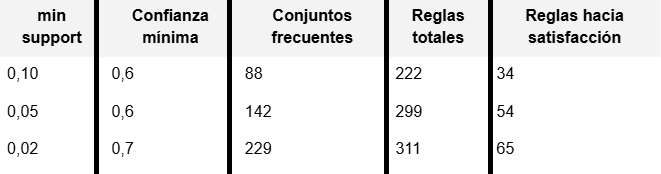

Prueba de parámetros
Probé tres combinaciones de parámetros. Con un support de 0,10 salieron pocas reglas y se pierden combinaciones útiles. Con 0,02 y confianza 0,7 salieron más reglas, pero incluyen combinaciones que cubren a menos del 5 % de los pasajeros, así que son menos representativas. Me quedé con un support de 0,05 y una confianza de 0,6, porque cada regla cubre al menos el 5 % de los pasajeros y quedan 54 reglas hacia la satisfacción, una cantidad manejable para interpretar.

**Reglas Interpretadas**

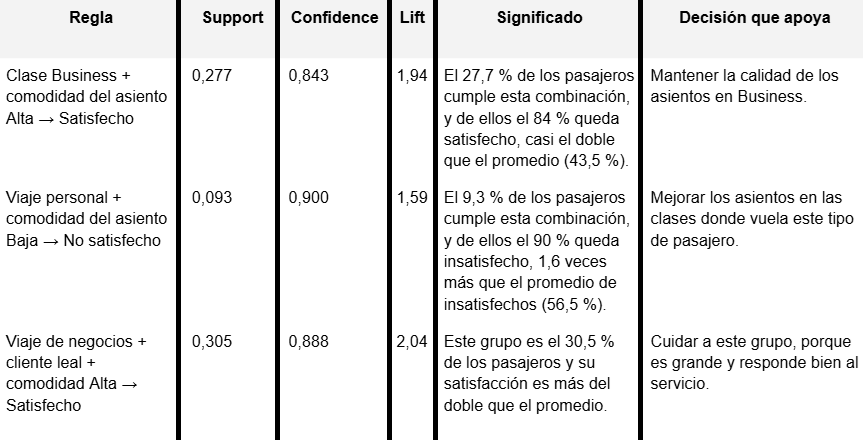

**Parte E — Árbol de decisión**
Fase CRISP-DM: identifícala tú.

In [51]:
y = df["satisfaction"]
X = pd.get_dummies(df.drop(columns=["satisfaction"]))
print(X.shape)

(129486, 26)


Elegí satisfaction como variable objetivo porque es lo que quiero explicar y es categórica con 2 clases (satisfecho y no satisfecho). Usé todas las demás columnas como variables de entrada, porque el árbol elige por sí solo las que le sirven. No descarté ninguna porque el dataset no trae identificadores ni nombres. Las columnas de texto las convertí en columnas de verdadero o falso, y las calificaciones las dejé como números de 0 a 5. Quedaron 129.486 filas y 26 columnas.

Entrené un árbol de decisión con profundidad máxima 4. Elegí ese límite para que el árbol sea legible y se pueda traducir a reglas de negocio. Un árbol mucho más profundo haría preguntas muy específicas que solo describen casos puntuales de estos datos, memorizaría detalles y sería imposible de leer.

In [52]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X, y)

DecisionTreeClassifier(max_depth=4, random_state=42)

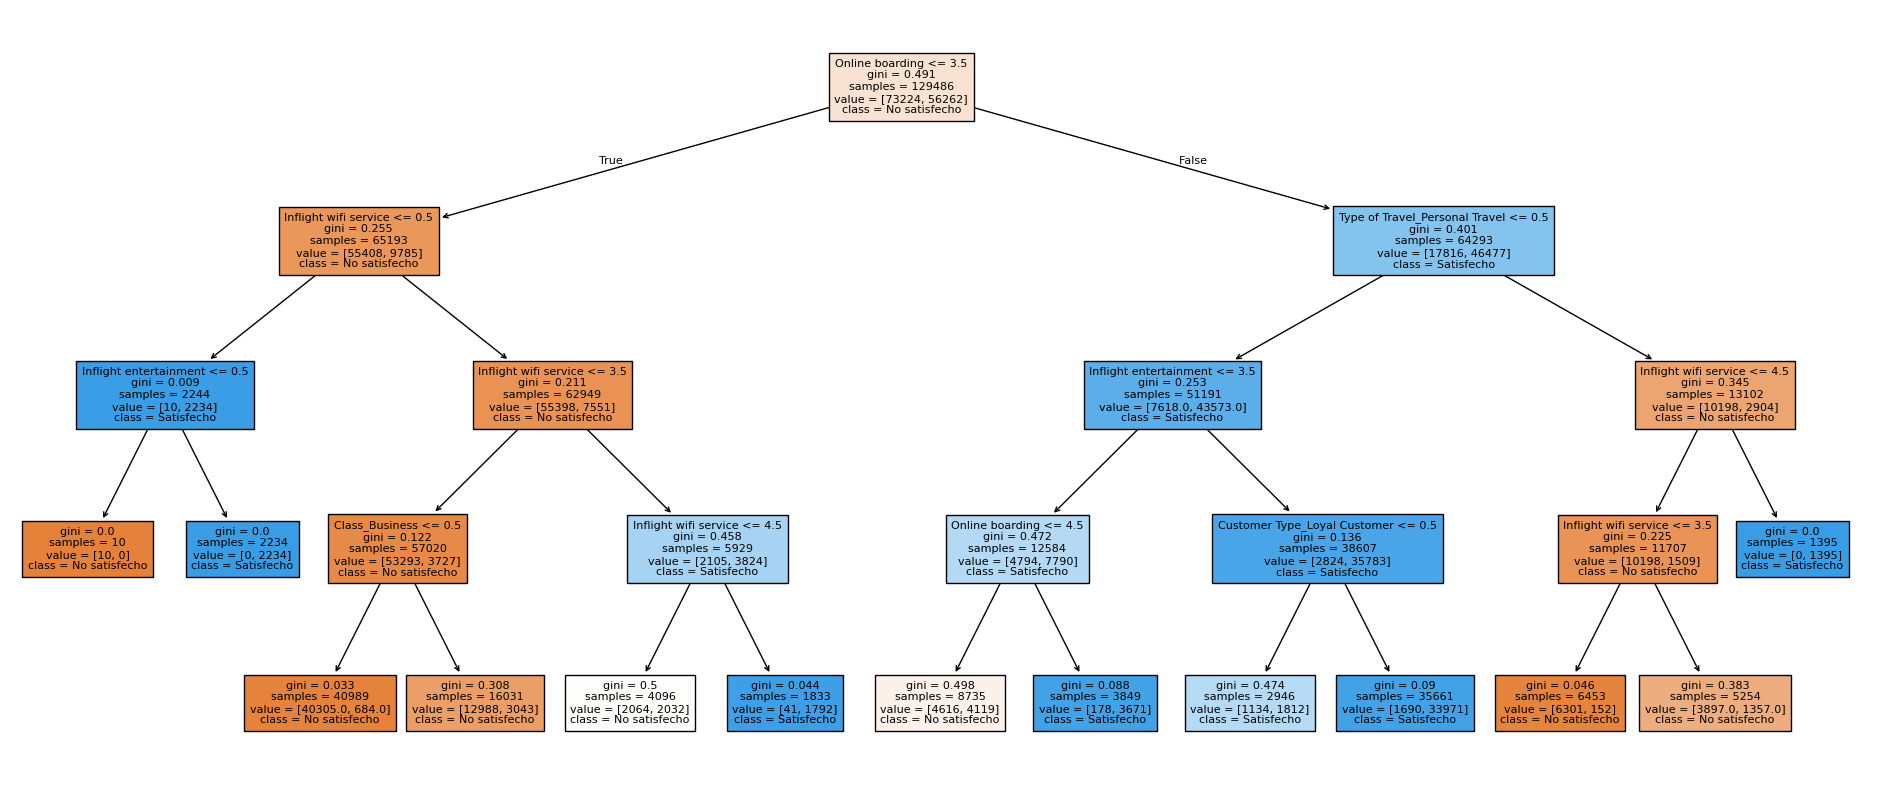

|--- Online boarding <= 3.50
|   |--- Inflight wifi service <= 0.50
|   |   |--- Inflight entertainment <= 0.50
|   |   |   |--- class: False
|   |   |--- Inflight entertainment >  0.50
|   |   |   |--- class: True
|   |--- Inflight wifi service >  0.50
|   |   |--- Inflight wifi service <= 3.50
|   |   |   |--- Class_Business <= 0.50
|   |   |   |   |--- class: False
|   |   |   |--- Class_Business >  0.50
|   |   |   |   |--- class: False
|   |   |--- Inflight wifi service >  3.50
|   |   |   |--- Inflight wifi service <= 4.50
|   |   |   |   |--- class: False
|   |   |   |--- Inflight wifi service >  4.50
|   |   |   |   |--- class: True
|--- Online boarding >  3.50
|   |--- Type of Travel_Personal Travel <= 0.50
|   |   |--- Inflight entertainment <= 3.50
|   |   |   |--- Online boarding <= 4.50
|   |   |   |   |--- class: False
|   |   |   |--- Online boarding >  4.50
|   |   |   |   |--- class: True
|   |   |--- Inflight entertainment >  3.50
|   |   |   |--- Customer Type_Loyal 

In [53]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 10))
plot_tree(arbol, feature_names=X.columns, class_names=["No satisfecho", "Satisfecho"],
          filled=True, fontsize=8)
plt.show()

print(export_text(arbol, feature_names=list(X.columns)))

In [54]:
print(export_text(arbol, feature_names=list(X.columns)))

|--- Online boarding <= 3.50
|   |--- Inflight wifi service <= 0.50
|   |   |--- Inflight entertainment <= 0.50
|   |   |   |--- class: False
|   |   |--- Inflight entertainment >  0.50
|   |   |   |--- class: True
|   |--- Inflight wifi service >  0.50
|   |   |--- Inflight wifi service <= 3.50
|   |   |   |--- Class_Business <= 0.50
|   |   |   |   |--- class: False
|   |   |   |--- Class_Business >  0.50
|   |   |   |   |--- class: False
|   |   |--- Inflight wifi service >  3.50
|   |   |   |--- Inflight wifi service <= 4.50
|   |   |   |   |--- class: False
|   |   |   |--- Inflight wifi service >  4.50
|   |   |   |   |--- class: True
|--- Online boarding >  3.50
|   |--- Type of Travel_Personal Travel <= 0.50
|   |   |--- Inflight entertainment <= 3.50
|   |   |   |--- Online boarding <= 4.50
|   |   |   |   |--- class: False
|   |   |   |--- Online boarding >  4.50
|   |   |   |   |--- class: True
|   |   |--- Inflight entertainment >  3.50
|   |   |   |--- Customer Type_Loyal 

In [55]:
importancias = pd.Series(arbol.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias.head(5).round(3))

aciertos = {}
for col in X.columns:
    m = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X[[col]], y)
    aciertos[col] = m.score(X[[col]], y)
print(pd.Series(aciertos).sort_values(ascending=False).head(5).round(3))

Online boarding                   0.516
Inflight wifi service             0.223
Type of Travel_Personal Travel    0.190
Inflight entertainment            0.042
Class_Business                    0.016
dtype: float64
Online boarding           0.787
Class_Business            0.752
Class_Eco                 0.715
Inflight wifi service     0.712
Inflight entertainment    0.702
dtype: float64


La primera pregunta del árbol es si la calificación del embarque online es 3 o menos. Se eligió primero porque es la pregunta que más reduce la mezcla de clases (el gini baja de 0,491 en la raíz a 0,255 en una rama y 0,401 en la otra). Según la importancia de variables, los atributos que más pesan son el embarque online (0,516), el wifi a bordo (0,223) y el viaje personal (0,190).

Revisé si alguna columna era casi equivalente a la satisfacción entrenando un árbol de una sola pregunta con cada columna. La que más acierta es el embarque online, con 78,7 %. Como responder siempre "no satisfecho" ya acierta el 56,5 %, no hay una fuga evidente.

Camino 1 (satisfechos): Si el embarque online tiene nota 4 o 5, el pasajero viaja por negocios, califica el entretenimiento a bordo con 4 o 5 y es cliente leal, entonces el árbol lo clasifica como satisfecho. En ese grupo, de unos 35.600 pasajeros (27,5 % del total), cerca del 95 % queda satisfecho. Es un grupo grande y muy satisfecho, así que conviene proteger la calidad del embarque online y del entretenimiento para los clientes leales en viajes de negocios.

Camino 2 (no satisfechos): Si el embarque online tiene nota 3 o menos, el wifi tiene nota entre 1 y 3 y el pasajero no viaja en Business (Eco o Eco Plus), el árbol lo clasifica como no satisfecho. En ese grupo, de unos 41.000 pasajeros (31,7 % del total), más del 98 % queda insatisfecho. Es el grupo más grande del árbol y casi todos quedan insatisfechos, así que mejorar el embarque online y el wifi en Eco es la acción con más potencial.

El árbol apoya decidir dónde invertir para mejorar la experiencia: el embarque online y el wifi a bordo son los factores que más separan a los pasajeros satisfechos de los que no lo están, sobre todo en clase Eco. Al igual que las reglas de asociación, el árbol muestra asociaciones, no causas.

**Parte F — Síntesis y proceso CRISP-DM**

**Qué aporta cada representación**

Las reglas de asociación muestran qué características aparecen juntas. Por ejemplo, los pasajeros Business con asiento muy cómodo suelen quedar satisfechos (lift 1,94). Sirven para explorar combinaciones sin una pregunta fija y se leen fácil. El árbol de decisión hace preguntas en orden y muestra cuáles separan mejor a los satisfechos de los no satisfechos. Sirve para ver qué factor mirar primero, por ejemplo el embarque online y el wifi.

**Cuándo usar cada una**

Uso las reglas cuando quiero descubrir combinaciones frecuentes, y el árbol cuando quiero saber qué factor pesa más para clasificar la satisfacción.

**Limitaciones con este dataset**

- Ambas muestran asociaciones, no causas.
- Las reglas usaron 5 columnas y el árbol 26, por eso destacan factores distintos: la comodidad del asiento en las reglas y el embarque online y el wifi en el árbol.
- El árbol está limitado a profundidad 4, así que simplifica los datos, y trata el 0 ("no calificado") como un número menor que 1.
- Las calificaciones son subjetivas y los datos vienen de una sola fuente.

## Parte G: Autoría y uso de herramientas

**Repositorio en GitHub:** https://github.com/Maurofome/Lab01_EDA_Aliaga_Mauricio

**Declaración de autoría:** Este trabajo es mío. Elegí el dataset, decidí qué columnas usar, qué datos limpiar y qué reglas y caminos del árbol interpretar, y puedo explicar cada parte del notebook.

**Uso de IA generativa:** Usé Claude (Anthropic) como apoyo durante el trabajo. Le pedí que me explicara los conceptos (support, confidence, lift, árbol de decisión), que me sugiriera código de ejemplo para pandas, mlxtend y scikit-learn, y que me diera borradores de algunos textos y de las tablas, que luego revisé y adapté. Las decisiones de limpieza, la elección de las columnas y de las reglas y las conclusiones las tomé yo.

**Fuente del dataset:** Airline Satisfaction Data, publicado en Kaggle por Arseniy Shutko.
Enlace: https://www.kaggle.com/datasets/arseniyshutko/binary-aviation-satisfaction-129k?resource=download
Licencia: CC0: Public Domain

**Mi aprendizaje principal:** En este trabajo aprendi y se me dio un mejor entendimiendo de la materia, ir tomando decisiones dependiendo del estado de la base de datos me parecio interesante como la falta de datos puede afectar la entrega de informacion.